/tmp/ipykernel_4978/693161992.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("^GSPC", start="2018-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


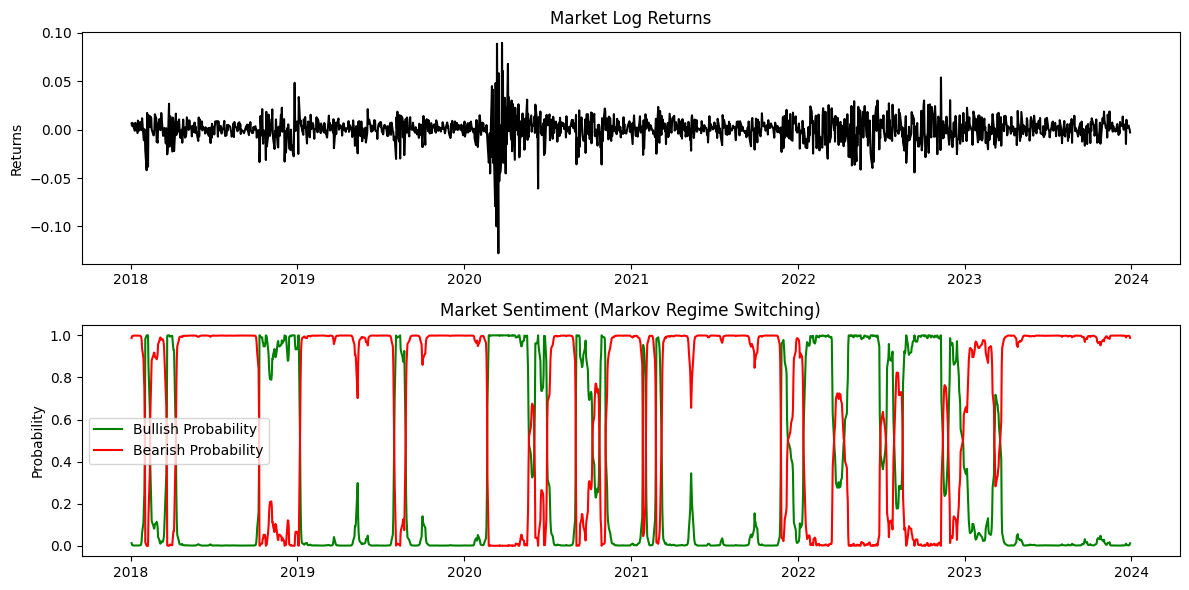

In [1]:
#Analysing market sentiment using Markov Regime switching model

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression

# 1. Load Market Data
data = yf.download("^GSPC", start="2018-01-01", end="2024-01-01")


# 2. Calculate Log Returns
data['returns'] = np.log(data['Close']).diff()
data.dropna(inplace=True)

# 3. Markov Regime Switching Model
model = MarkovRegression(
    data['returns'],
    k_regimes=2,          # Bull & Bear
    trend='c',
    switching_variance=True
)

result = model.fit()

# 4. Regime Probabilities
probs = result.smoothed_marginal_probabilities

data['Bear_Prob'] = probs[0]
data['Bull_Prob'] = probs[1]

# 5. Visualization (Matplotlib Only)
plt.figure(figsize=(12, 6))

# Plot market returns
plt.subplot(2, 1, 1)
plt.plot(data.index, data['returns'], color='black')
plt.title("Market Log Returns")
plt.ylabel("Returns")

# Plot regime probabilities
plt.subplot(2, 1, 2)
plt.plot(data.index, data['Bull_Prob'], label="Bullish Probability", color='green')
plt.plot(data.index, data['Bear_Prob'], label="Bearish Probability", color='red')
plt.title("Market Sentiment (Markov Regime Switching)")
plt.ylabel("Probability")
plt.legend()

plt.tight_layout()
plt.show()